In [513]:
%load_ext autoreload
%autoreload 2

import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy
import torch
import nibabel as nb

from tqdm.auto import tqdm
from os.path import join as pjoin

DATA7_PATH = "/System/Volumes/Data/data/data7"
projects_path = f"{DATA7_PATH}/network_control/projects"
sys.path.insert(1, projects_path)

import voxel_analysis as va
import torch_math_tools as tmt
import CAP_tools

NC_path = f"{DATA7_PATH}/network_control/projects/network_control"
sys.path.insert(1, NC_path)
import surface_mapping as sfm
import load
import plot

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load Data:
### Load Subjects [] remove this stuff

In [2]:
_, _, _, subject_list = load.load_constants(400)

In [3]:
param_dir = "/data/data7/network_control/scripts/_params"
HCP_CAP_param_prefix = pjoin(param_dir, "HCP_7T_CAP_analysis/HCP_7T_CAP_analysis")

get_HCP_cifti_list = lambda session, cifti_type: f"{HCP_CAP_param_prefix}_{session}_{cifti_type}_list.txt"

def get_cifti_paths(cifti_list_path):
    with open(cifti_list_path, "r") as file:
        return file.read().strip().split()

def filter_sort_cifti_paths(paths, subjects):
    filtered_paths = [p for p in paths if any(subj in p for subj in subjects)]
    assert len(filtered_paths) == len(subjects)
    key = lambda path: next(i for i, subj in enumerate(subjects) if subj in path)
    return sorted(filtered_paths, key=key)

def get_HCP_cifti_paths(session, cifti_type, subject_list):
    cifti_list_path = get_HCP_cifti_list(session, cifti_type)
    cifti_paths = get_cifti_paths(cifti_list_path)
    cifti_paths = filter_sort_cifti_paths(cifti_paths, subject_list)
    return cifti_paths

### Load Ciftis

In [4]:
session = "tfMRI_MOVIE_7T_DAY_1"
# session = "rfMRI_REST1_7T_PA"

dtseries_paths = get_HCP_cifti_paths(session, "dtseries", subject_list)
ptseries_paths = get_HCP_cifti_paths(session, "400_ptseries", subject_list)

In [5]:
subject_index = 0

dtseries = nb.load(dtseries_paths[subject_index])
ptseries = nb.load(ptseries_paths[subject_index])
voxel_data = dtseries.get_fdata()
parcel_data = ptseries.get_fdata()

In [6]:
dtseries_paths[subject_index]

'/System/Volumes/Data/data/data7/HCP_7T/100610/MNINonLinear/Results/tfMRI_MOVIE_7T_DAY_1/tfMRI_MOVIE_7T_DAY_1_Atlas_hp2000_clean_nilearn_ISCH.dtseries.nii'

### Cifti Map to Full Arrays

In [7]:
def hemisphere_to_full(values):
    """ """
    return np.concat([values["left"], values["right"]], axis=-1)

def full_to_hemi(values):
    n_half = values.shape[-1] // 2
    return {"left": values.T[:n_half].T, "right": values.T[n_half:].T}

# Core Functional Connectivity Analysis

In [8]:
def get_cortex_data(full_data, cifti):
    pax = cifti.header.get_axis(1)
    slice_LUT = {structure: sl for structure, sl,_  in pax.iter_structures()}
    cortex_data_L = full_data[:, slice_LUT["CIFTI_STRUCTURE_CORTEX_LEFT"]]
    cortex_data_R = full_data[:, slice_LUT["CIFTI_STRUCTURE_CORTEX_RIGHT"]]
    return np.hstack([cortex_data_L, cortex_data_R])

In [9]:
priors_path = os.path.join(projects_path, "voxel_analysis/resources/priors.mat")

priors = scipy.io.loadmat(priors_path)
FC, spatial, network_labels, _ = priors["Priors"][0, 0]
network_labels = np.array([lab[0][0] for lab in network_labels])
FC, spatial = FC.T, spatial.T

In [10]:
example_cifti = nb.load(va.constants.EXAMPLE_DTSERIES)

Text(0.5, 1.0, 'Frontoparietal Functional Connectivity')

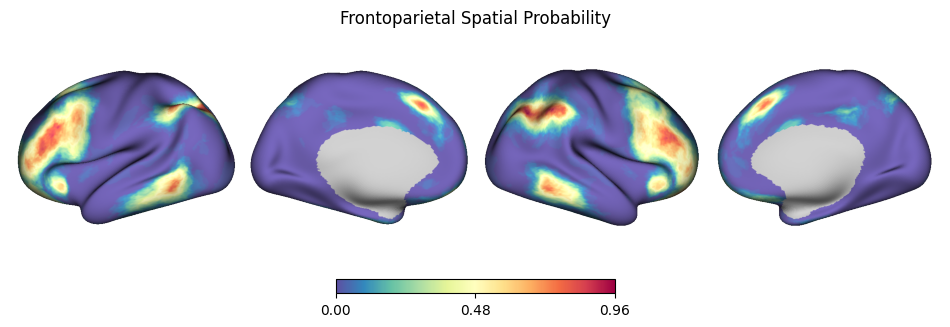

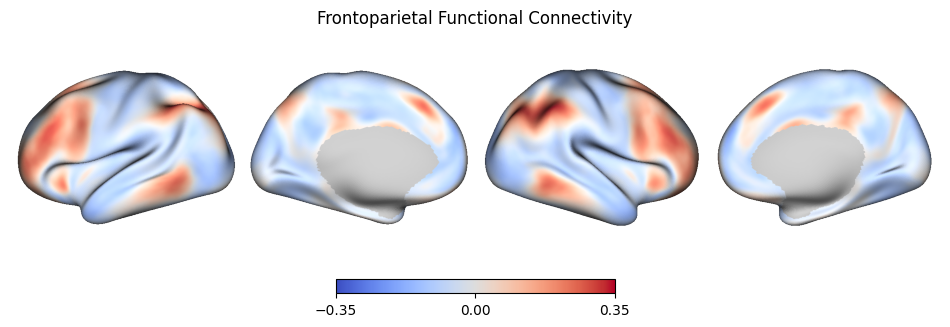

In [11]:
i = 8
spatial_values_i = CAP_tools.utils.cifti_map(None, spatial[i], example_cifti)
FC_values_i = CAP_tools.utils.cifti_map(None, FC[i], example_cifti)

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(spatial_values_i, cmap=plt.cm.Spectral_r, ax=ax)
ax.set_title(f"{network_labels[i]} Spatial Probability")

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(FC_values_i, cmap=plt.cm.coolwarm, ax=ax)
ax.set_title(f"{network_labels[i]} Functional Connectivity")

In [12]:
full_data = example_cifti.get_fdata()
vertex_data = get_cortex_data(full_data, example_cifti)

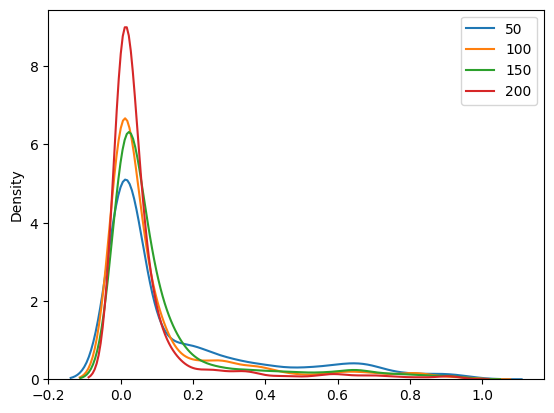

In [13]:
k_partition = 50

remove_diag = lambda array: array[~np.eye(array.shape[0], dtype=bool)]
for k_step in range(1, 5):
    hf_ind = np.argpartition(spatial[0], -k_partition * k_step)[-k_partition * k_step:][:k_partition]
    hf_roi_vertices = vertex_data[:, hf_ind]
    sns.kdeplot(remove_diag(np.corrcoef(hf_roi_vertices.T)).ravel() ** 2, bw_method=0.2, label=k_step * k_partition)
plt.legend()

In [14]:
def torch_corr(a, b, **devp):
    """ """
    a = torch.tensor(a.astype("float32"), **devp).T
    b = torch.tensor(b.astype("float32"), **devp).T

    cor = torch.matmul(a, b.T) / (torch.norm(a, dim=1, keepdim=True) * torch.norm(b, dim=1))
    return cor.cpu().numpy()

def np_corr(a, b):
    """ """
    a, b = a.T, b.T
    cor = np.matmul(a, b.T) / (np.linalg.norm(a, axis=1, keepdims=True) * np.linalg.norm(b, axis=1))
    return cor  

In [15]:
si = spatial[i] >= 0.80
print("Non Zero Mask Count: ", np.count_nonzero(si))

Non Zero Mask Count:  417


In [16]:
hf_roi_vertices = vertex_data[:, si]
vertex_data[:, ~si].shape

(1859, 58995)

In [27]:
devp = dict(device="mps")

a = hf_roi_vertices
b = vertex_data[:, :]
# a = np.mean(a, axis=1).reshape(-1, 1)

cor = torch_corr(a, vertex_data, **devp)
cor[cor < 0.2] = 0
# cor[:, si] = 0
# cor = np.mean(cor, axis=0).reshape(1, -1)
w = spatial[i][si] ** 2
w /= np.sum(spatial[i][si])
cor = np.sum(w.reshape(-1, 1) * cor, axis=0, keepdims=True)

IndexError: index 53 is out of bounds for axis 0 with size 21

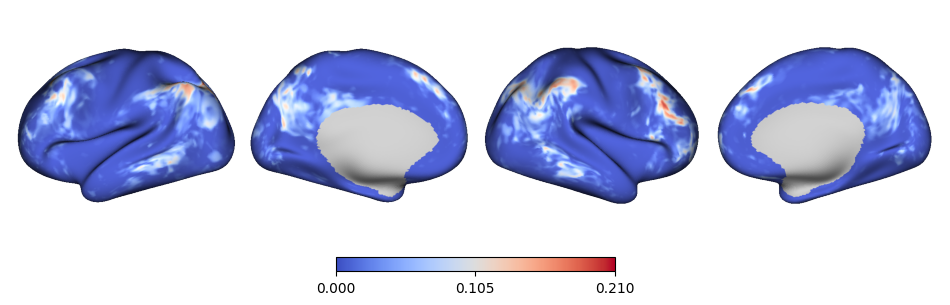

In [501]:
sfc_values_i = CAP_tools.utils.cifti_map(None, cor[0], example_cifti)

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(sfc_values_i, cmap=plt.cm.coolwarm, ax=ax)
ax.set_title(f"{network_labels[i]} Spatial Restricted FC")

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(spatial_values_i, cmap=plt.cm.Spectral_r, ax=ax)
ax.set_title(f"{network_labels[i]} Spatial Values")

In [30]:
rs_dtseries_list_path = "/data/data7/network_control/scripts/_params/EC_CAP_analysis/EC_CAP_analysis_RS_fMRI_maps_dtseries_list.txt"

In [31]:
with open(rs_dtseries_list_path, "r") as f:
    dtseries_paths = f.read().strip().split()

subject_list = [path.split("/MNI")[0].split("/")[-1] for path in dtseries_paths]

In [32]:
def get_raw_core_FC(cifti_path, si):
    """ """
    cifti = nb.load(cifti_path)
    full_data = cifti.get_fdata()
    vertex_data = get_cortex_data(full_data, cifti)

    devp = dict(device="mps")
    cor = torch_corr(vertex_data[:, si], vertex_data, **devp)
    return cor

In [1042]:
w = spatial[i][si] ** 2
w /= np.sum(spatial[i][si])
cor = np.sum(w.reshape(-1, 1) * cor, axis=0, keepdims=True)

In [ ]:
raw_cor_set = []
for path in tqdm(dtseries_paths):
    raw_cor_set.append(get_raw_core_FC(path, si))
    # pass

  0%|          | 0/54 [00:00<?, ?it/s]

pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-

In [103]:
raw_cor_set = np.array(raw_cor_set)

In [162]:
cor_set = raw_cor_set.copy()
cor_set[cor_set < 0] = 0

In [190]:
w = spatial[i][si].reshape(-1, 1) #** 2
w /= np.sum(spatial[i][si])

In [199]:
cor_m_set = np.array([np.sum(w * cor_i, axis=0, keepdims=False) for cor_i in cor_set])

In [200]:
szp_label = np.array(["_08_" in s for s in subject_list])

In [201]:
szp_m = np.mean(cor_m_set[szp_label], axis=0)
hc_m = np.mean(cor_m_set[~szp_label], axis=0)

In [194]:
fc_content = np.nanmean(cor_m_set, axis=1)

In [195]:
t, p = scipy.stats.ttest_ind(fc_content[szp_label], fc_content[~szp_label])
print(p)

0.6637101967141563


<Axes: >

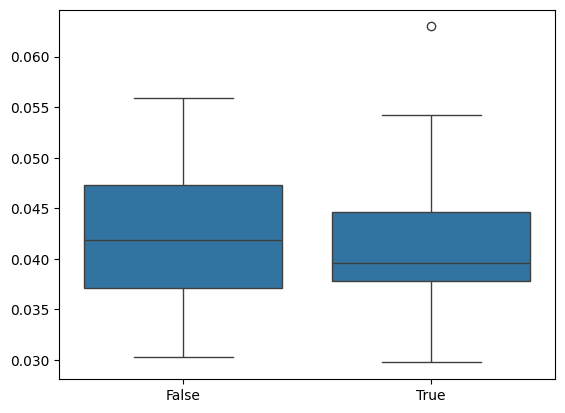

In [196]:
sns.boxplot(y=fc_content, x=szp_label)

In [197]:
t_s, p_s = scipy.stats.ttest_ind(cor_m_set[szp_label], cor_m_set[~szp_label])

In [180]:
p_s[np.isnan(p_s)] = 1

In [181]:
q_s = scipy.stats.false_discovery_control(p_s)

Text(0.5, 1.0, 'HC Default_Parietal Spatial Restricted FC')

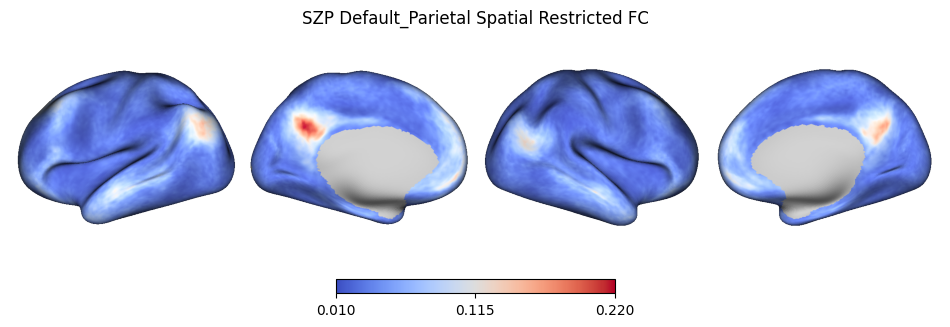

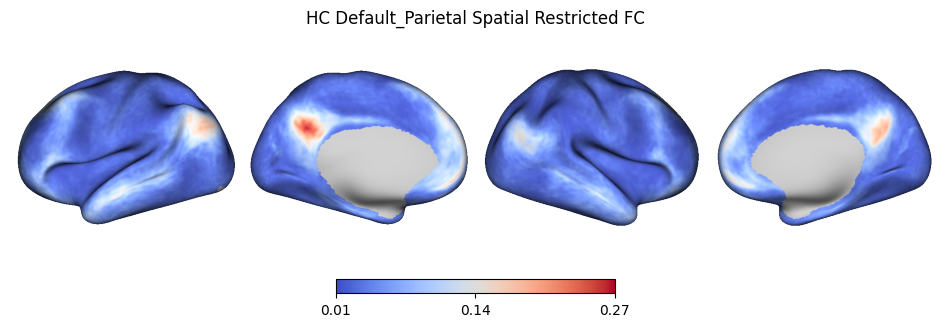

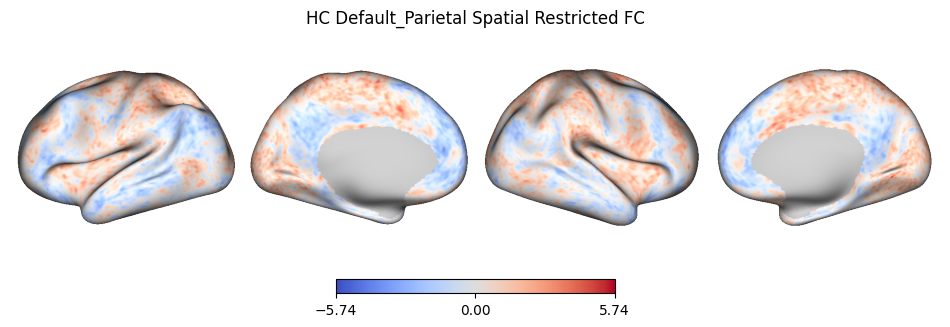

In [182]:
szp_m_values = CAP_tools.utils.cifti_map(None, szp_m, example_cifti)

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(szp_m_values, cmap=plt.cm.coolwarm, ax=ax)
ax.set_title(f"SZP {network_labels[i]} Spatial Restricted FC")

hc_m_values = CAP_tools.utils.cifti_map(None, hc_m, example_cifti)
fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(hc_m_values, cmap=plt.cm.coolwarm, ax=ax)
ax.set_title(f"HC {network_labels[i]} Spatial Restricted FC")

t_values = CAP_tools.utils.cifti_map(None, t_s, example_cifti)
fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(t_values, cmap=plt.cm.coolwarm, ax=ax)
ax.set_title(f"HC {network_labels[i]} Spatial Restricted FC")

# Load infomaps dlabels and assign to network

In [211]:
import glob
pm_dir = "/data/data7/network_control/results/EC_analysis/precision_maps/RS_fMRI_maps"

# dlabel_paths = glob.glob(pm_dir + "/*/*.dlabel.nii")
# dlabel = nb.load(dlabel_paths[0])

In [212]:
# t_values = CAP_tools.utils.cifti_map(None, dlabel.get_fdata()[0], dlabel)
# fig, ax = plt.subplots(figsize=(12, 4))
# ax, _ = sfm.surface_plot(t_values, cmap=plt.cm.coolwarm, ax=ax)
# ax.set_title(f"HC {network_labels[i]} Spatial Restricted FC")

Text(0.5, 1.0, 'HC Frontoparietal Spatial Restricted FC')

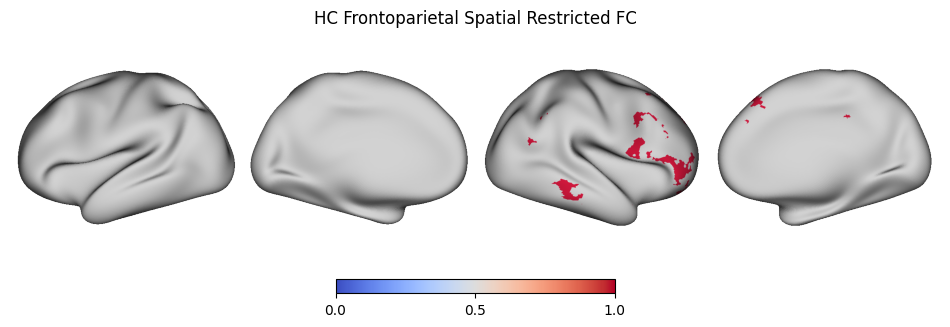

In [144]:
roi_ind = vertex_labels == 360

t_values = CAP_tools.utils.cifti_map(None, roi_ind, dlabel)
fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(t_values, cmap=plt.cm.coolwarm, ax=ax)
ax.set_title(f"HC {network_labels[i]} Spatial Restricted FC")

In [200]:
def get_partition_cortex(partition, cifti):
    """ """
    _, partition = va.pm.process_partition(partition, cifti)
    vertex_labels = np.full(np.max(partition[0]) + 1, fill_value=np.nan)
    vertex_labels[partition[0]] = partition[1]
    return get_cortex_data(vertex_labels.reshape(1, -1), cifti)[0]

In [201]:
partition_paths = glob.glob(pm_dir + "/*/*parcellation*")

In [230]:
partition = np.load(partition_paths[0])
vertex_labels = get_partition_cortex(partition, example_cifti)

Context leak detected, msgtracer returned -1


Text(0.5, 1.0, 'HC Frontoparietal Spatial Restricted FC')

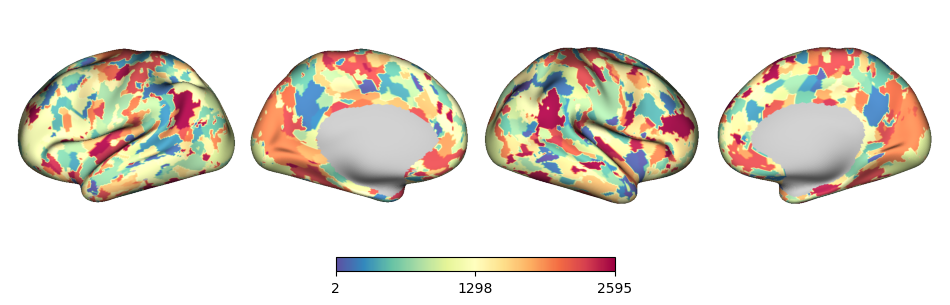

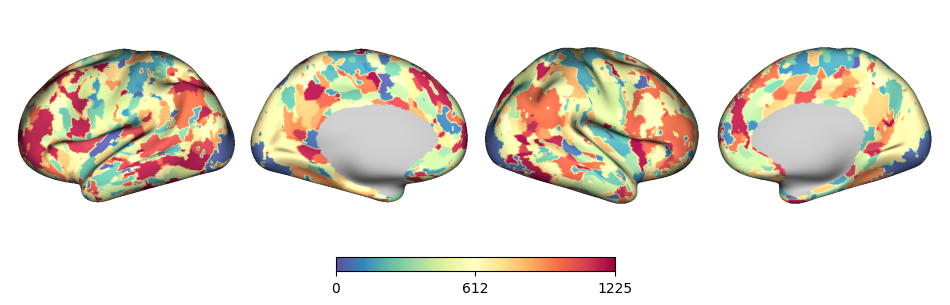

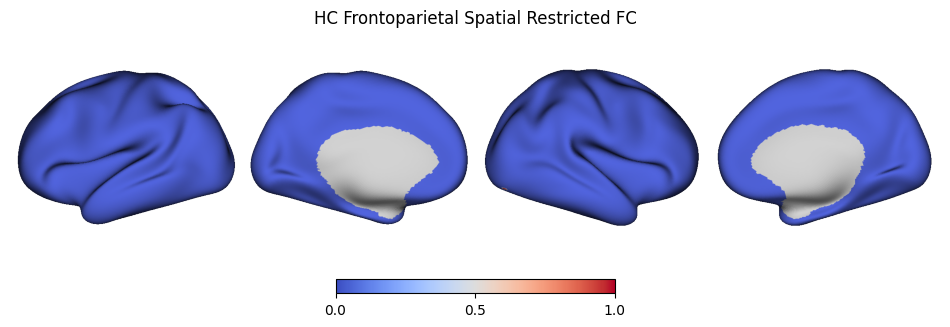

In [231]:
sfm.surface_plot(precision_map_values, cmap=plt.cm.Spectral_r)
vl_values = CAP_tools.utils.cifti_map(None, vertex_labels, example_cifti)
sfm.surface_plot(vl_values, cmap=plt.cm.Spectral_r)

roi_ind = vertex_labels == 0

t_values = CAP_tools.utils.cifti_map(None, roi_ind, example_cifti)
fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(t_values, cmap=plt.cm.coolwarm, ax=ax)
ax.set_title(f"HC {network_labels[i]} Spatial Restricted FC")

In [596]:
def get_spatial_assignments(vertex_labels, spatial, network_labels, nan_fill="Noise"):
    """ """
    # spatial correlation
    label_to_network = {}
    
    for cluster_label in tqdm(np.unique(vertex_labels), leave=False):
        roi_index = vertex_labels == cluster_label
        
        sp_cor = torch_corr(spatial.T, roi_index.reshape(-1, 1)* 1)
        sp_index = np.argmax(torch_corr(spatial.T, roi_index.reshape(-1, 1)* 1))
        label_to_network[cluster_label] = sp_index
    vertex_networks = np.array([label_to_network.get(i, -1) for i in vertex_labels])
    network_label_dict = dict(enumerate(network_labels))
    vertex_networks_str = np.array([network_label_dict.get(i, nan_fill) for i in vertex_networks])
    return vertex_networks, vertex_networks_str

In [597]:
vertex_networks, vertex_networks_str = get_spatial_assignments(vertex_labels, spatial, network_labels)

  0%|          | 0/950 [00:00<?, ?it/s]

In [601]:
partition = np.load(partition_paths[0])
vertex_labels = get_partition_cortex(partition, example_cifti)
vertex_networks, vertex_networks_str = get_spatial_assignments(vertex_labels, spatial, network_labels)

  0%|          | 0/720 [00:00<?, ?it/s]

In [602]:
na_s, ns_s = [], []
valid_subjects = []
for i, partition_path in enumerate(tqdm(partition_paths)):
    partition = np.load(partition_path)
    if len(np.unique(partition[1])) > 4000:
        print("skipped ", i)
        continue

    vertex_labels = get_partition_cortex(partition, example_cifti)
    vertex_networks, vertex_networks_str = get_spatial_assignments(vertex_labels, spatial, network_labels)
    na_s.append(vertex_networks)
    ns_s.append(vertex_networks_str)
    valid_subjects.append(subject_list[i])

  0%|          | 0/54 [00:00<?, ?it/s]

  0%|          | 0/720 [00:00<?, ?it/s]

skipped  1


  0%|          | 0/799 [00:00<?, ?it/s]

  0%|          | 0/814 [00:00<?, ?it/s]

...

  0%|          | 0/891 [00:00<?, ?it/s]

  0%|          | 0/1460 [00:00<?, ?it/s]

  0%|          | 0/816 [00:00<?, ?it/s]

skipped  52


  0%|          | 0/950 [00:00<?, ?it/s]

In [629]:
na_s, ns_s = np.array(na_s), np.array(ns_s)
valid_subjects = np.array(valid_subjects)
szp_index = np.array(["_08_" in v for v in valid_subjects])

In [605]:
z = np.array([(ns_s == net).mean(axis=1) for net in network_labels]).T
df = pd.DataFrame(z, columns=network_labels)
df["subject"] = valid_subjects[nvi]
df["szp"] = np.array(["HC", "Szp"])[df["subject"].str.contains("_08_") * 1]

In [606]:
mdf = pd.melt(df, id_vars=["subject", "szp"], var_name="network", value_name="n_vertices")

<Axes: xlabel='n_vertices', ylabel='network'>

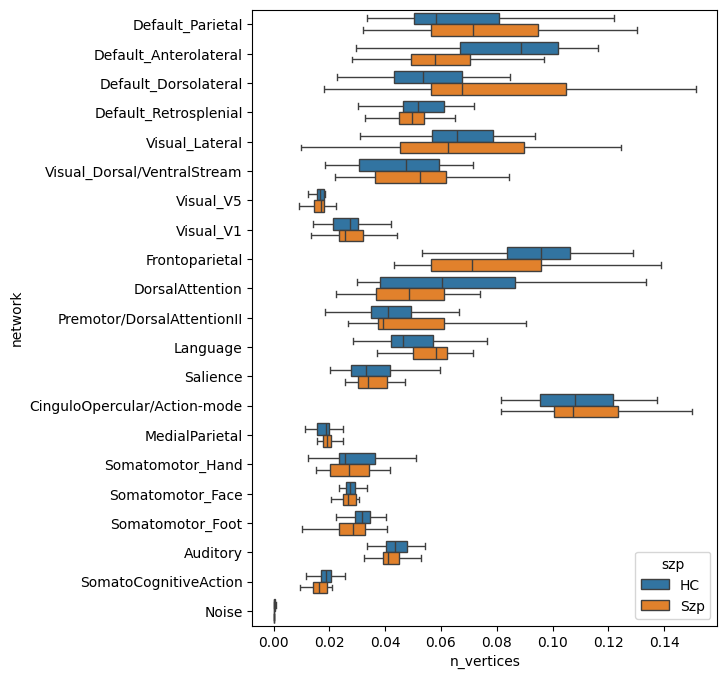

In [607]:
fig, ax = plt.subplots(figsize=(6, 8))
sns.boxplot(data=mdf, y="network", x="n_vertices", hue="szp", showfliers=False, ax=ax)

In [608]:
szp_df = df.loc[df["szp"] == "Szp"]
hc_df = df.loc[df["szp"] != "Szp"]

In [609]:
t_s, p_s = scipy.stats.ttest_ind(szp_df[network_labels], hc_df[network_labels])

q_s = np.ones(len(p_s))
q_s[~np.isnan(p_s)] = scipy.stats.false_discovery_control(p_s[~np.isnan(p_s)])

In [610]:
sig_index = p_s < 0.05
network_labels[sig_index], p_s[sig_index]

(array(['Default_Anterolateral', 'Default_Dorsolateral', 'Frontoparietal',
        'Language'], dtype='<U28'),
 array([0.01313558, 0.03769052, 0.01138422, 0.01482338]))

In [611]:
szp_m_sizes = szp_df[network_labels].mean()
hc_m_sizes = hc_df[network_labels].mean()
size_ratio = szp_m_sizes / hc_m_sizes

In [612]:
size_ratio[sig_index], size_ratio

(Default_Anterolateral    0.773411
 Default_Dorsolateral     1.339891
 Frontoparietal           0.813702
 Language                 1.220512
 dtype: float64,
 Default_Parietal                1.069296
 Default_Anterolateral           0.773411
 Default_Dorsolateral            1.339891
 Default_Retrosplenial           0.943006
 Visual_Lateral                  0.931047
 Visual_Dorsal/VentralStream     1.184224
 Visual_V5                       0.867877
 Visual_V1                       0.971890
 Frontoparietal                  0.813702
 DorsalAttention                 0.891756
 Premotor/DorsalAttentionII      1.173426
 Language                        1.220512
 Salience                        1.023005
 CinguloOpercular/Action-mode    1.025910
 MedialParietal                  1.053989
 Somatomotor_Hand                1.183210
 Somatomotor_Face                0.961243
 Somatomotor_Foot                0.857953
 Auditory                        1.003034
 SomatoCognitiveAction           0.895601
 No

### demographic correlations

In [613]:
demo_path = "/data/data7/network_control/resources/excel/GBU_tasit_demographics_all.tsv"

pdf = pd.read_csv(demo_path, sep="\t")
pdf["subject"] = pdf["PCode"]
pdf = pdf.merge(df, on="subject").reset_index(drop=True)

zpdf = pdf.query("szp == 'Szp'").reset_index(drop=True)

In [614]:
cols = ['AGE', 'Age at test', 'CPZTotal', 'ER40_Total', 'ER40_Total_Per',
       'Edinburgh score', 'Gender', 'PANSS_Neg_3F','PANSS_Pos_3F', 'PANSS_Tot_3F',
       'PSIComposite_ScaledScore', 'Participant SES', 'ProcessingSpeedIndex', 'Sarcasm_total',
       'TotalCorrect', 'TotalLiesCorrect', 'TotalSarcCorrect', 'WRAT_ScaledScore',
       'highest grade achieved',
       'Default_Parietal', 'Default_Anterolateral', 'Default_Dorsolateral',
       'Default_Retrosplenial', 'Visual_Lateral',
       'Visual_Dorsal/VentralStream', 'Visual_V5', 'Visual_V1',
       'Frontoparietal', 'DorsalAttention', 'Premotor/DorsalAttentionII',
       'Language', 'Salience', 'CinguloOpercular/Action-mode',
       'MedialParietal', 'Somatomotor_Hand', 'Somatomotor_Face',
       'Somatomotor_Foot', 'Auditory', 'SomatoCognitiveAction', 'Noise']

cols = network_labels[sig_index]

In [615]:
dem_vars = ["AGE", 'CPZTotal', 'ER40_Total', 'ER40_Total_Per',
           'Edinburgh score', 'Gender', 'PANSS_Neg_3F','PANSS_Pos_3F', 'PANSS_Tot_3F',
           'PSIComposite_ScaledScore', 'Participant SES', 'ProcessingSpeedIndex', 'Sarcasm_total',
           'TotalCorrect', 'TotalLiesCorrect', 'TotalSarcCorrect', 'WRAT_ScaledScore']

size_vars = network_labels[sig_index]

print("Szp")
for var1 in dem_vars:
    for var2 in size_vars:
        
        cdf = zpdf[[var1, var2]].dropna()        
        r, p = scipy.stats.pearsonr(cdf[var1], cdf[var2])
        if p < 0.05:
            s = f"{var1} - {var2}"
            print(s + f"{' ' * (35 - len(s))}:: R^2 = {r:.02f} {p:0.2f}")


print("\n\nHealthy Controls")
for var1 in dem_vars:
    for var2 in size_vars:
        cdf = pdf[[var1, var2]].dropna()        
        r, p = scipy.stats.pearsonr(cdf[var1], cdf[var2])
        if p < 0.05:
            s = f"{var1} - {var2}"
            print(s + f"{' ' * (35 - len(s))}:: R^2 = {r:.02f} {p:0.2f}")

print("\n\nAll Subjects")
for var1 in dem_vars:
    for var2 in size_vars:
        cdf = pdf[[var1, var2]].dropna()        
        r, p = scipy.stats.pearsonr(cdf[var1], cdf[var2])
        if p < 0.05:
            s = f"{var1} - {var2}"
            print(s + f"{' ' * (35 - len(s))}:: R^2 = {r:.02f} {p:0.2f}")

Szp
AGE - Default_Dorsolateral         :: R^2 = 0.51 0.02
Edinburgh score - Language         :: R^2 = 0.46 0.04
TotalCorrect - Language            :: R^2 = -0.49 0.02
TotalLiesCorrect - Language        :: R^2 = -0.45 0.04
TotalSarcCorrect - Language        :: R^2 = -0.45 0.04


Healthy Controls
AGE - Default_Dorsolateral         :: R^2 = 0.49 0.00
ER40_Total - Default_Dorsolateral  :: R^2 = -0.35 0.03
ER40_Total_Per - Default_Dorsolateral:: R^2 = -0.33 0.04
Gender - Default_Anterolateral     :: R^2 = -0.39 0.02
PSIComposite_ScaledScore - Language:: R^2 = -0.39 0.02
ProcessingSpeedIndex - Language    :: R^2 = -0.37 0.02
TotalCorrect - Language            :: R^2 = -0.49 0.00
TotalLiesCorrect - Language        :: R^2 = -0.35 0.03
TotalSarcCorrect - Language        :: R^2 = -0.47 0.00
WRAT_ScaledScore - Default_Anterolateral:: R^2 = 0.41 0.01
WRAT_ScaledScore - Language        :: R^2 = -0.36 0.04


All Subjects
AGE - Default_Dorsolateral         :: R^2 = 0.49 0.00
ER40_Total - Default_Dors

In [572]:
var_set = ["ProcessingSpeedIndex", "TotalCorrect"]
cdf = pdf[var_set].dropna()
scipy.stats.pearsonr(cdf[var_set[0]], cdf[var_set[1]])

PearsonRResult(statistic=np.float64(0.41280533788711987), pvalue=np.float64(0.011111024639345478))

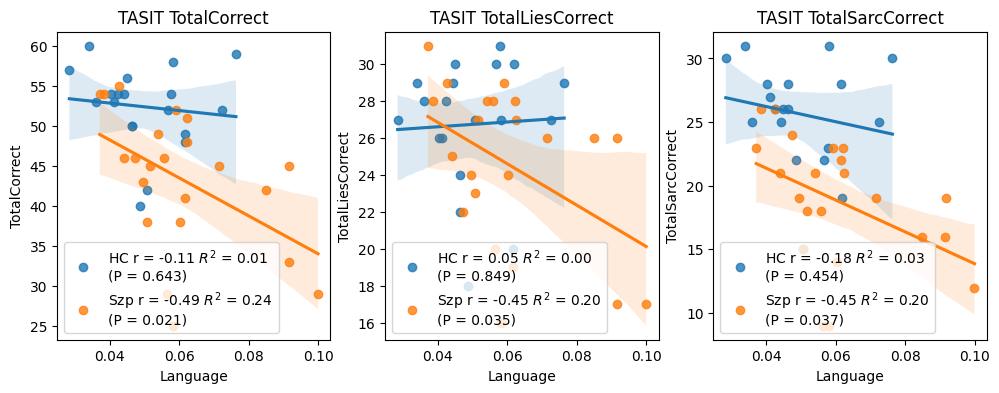

In [616]:
clin_vars = ["TotalCorrect", "TotalLiesCorrect", "TotalSarcCorrect"]
hc_pdf = pdf.query("szp == 'HC'")
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
ax = axes[0]
for ax, var in zip(axes, clin_vars):
    plot.regplot(hc_pdf["Language"], hc_pdf[var], label="HC", ax=ax)
    plot.regplot(zpdf["Language"], zpdf[var], label="Szp", ax=ax)
    ax.set(title=f"TASIT {var}")

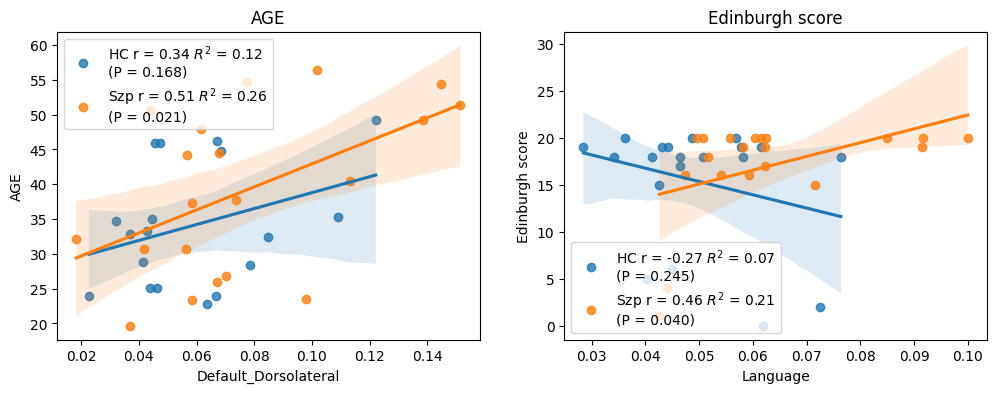

In [617]:
other_vars = ["AGE", "Edinburgh score"]
size_vars = ["Default_Dorsolateral", "Language"]
hc_pdf = pdf.query("szp == 'HC'")
fig, axes = plt.subplots(1, len(other_vars), figsize=(12, 4))
for ax, var, svar in zip(axes, other_vars, size_vars):
    plot.regplot(hc_pdf[svar], hc_pdf[var], label="HC", ax=ax)
    plot.regplot(zpdf[svar], zpdf[var], label="Szp", ax=ax)
    ax.set(title=var)

In [628]:
network_interest = "Language"

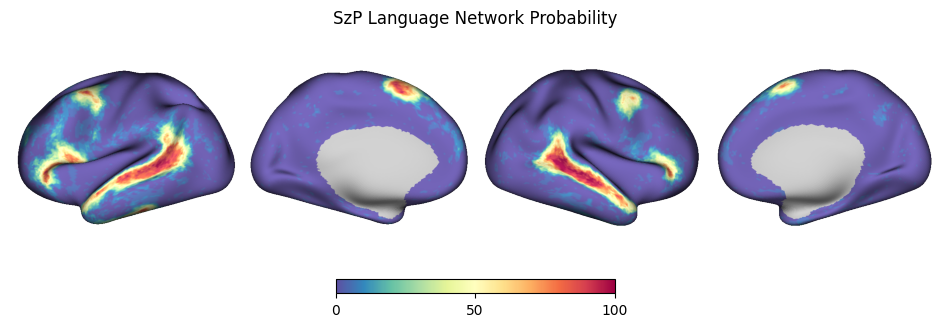

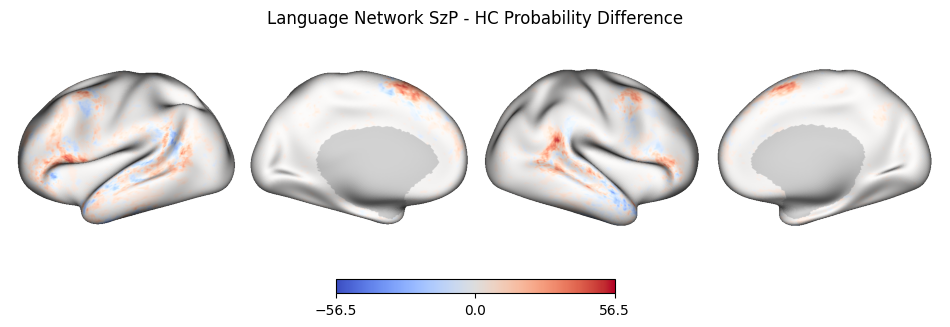

In [686]:
nl = ns_s == network_interest
szp_net_prob = nl[szp_index].mean(axis=0) * 100

szp_net_prob_values = CAP_tools.utils.cifti_map(None, szp_net_prob, example_cifti)
fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(szp_net_prob_values, cmap=plt.cm.Spectral_r, ax=ax)
ax.set_title(f"SzP {network_interest} Network Probability")

hc_net_prob = nl[~szp_index].mean(axis=0) * 100
# hc_net_prob_values = CAP_tools.utils.cifti_map(None, hc_net_prob, example_cifti)
# fig, ax = plt.subplots(figsize=(12, 4))
# ax, _ = sfm.surface_plot(hc_net_prob_values, cmap=plt.cm.Spectral_r, ax=ax)
# ax.set_title(f"HC {network_interest} Network Probability")

# odds_prob = np.log2(np.clip(szp_net_prob / hc_net_prob, 0.05, 10))
# odds_prob_values = CAP_tools.utils.cifti_map(None, odds_prob, example_cifti)
# fig, ax = plt.subplots(figsize=(12, 4))
# ax, _ = sfm.surface_plot(odds_prob_values, cmap=plt.cm.coolwarm, ax=ax)
# ax.set_title(f"{network_interest} Network SzP - HC Log Odds Ratio")

prob_diff = szp_net_prob - hc_net_prob
prob_diff_values = CAP_tools.utils.cifti_map(None, prob_diff, example_cifti)
fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(prob_diff_values, cmap=plt.cm.coolwarm, ax=ax)
ax.set_title(f"{network_interest} Network SzP - HC Probability Difference")

sfm.write_values_to_dscalar(
    prob_diff_values,
    "/data/data7/network_control/projects/voxel_analysis/tests/outputs/ex.dscalar.nii",
    scalar_name="SzP - HC Language Network Probability"
                           )

In [673]:
parc = sfm.Parcellation("TASIT_topo_roi131")

In [715]:
topo_roi_values = {}
for lab in sorted(parc.rh_label_indices.keys()):
    if lab == "???":
        continue
    ind = parc.rh_label_indices[lab]
    
    topo_roi_values[lab] = np.nanmean(prob_diff_values["right"][ind])

/var/folders/p0/zng86kys7t3578bm_dw7qjym00014h/T/ipykernel_71129/1944918855.py:7: RuntimeWarning: Mean of empty slice
  topo_roi_values[lab] = np.nanmean(prob_diff_values["right"][ind])


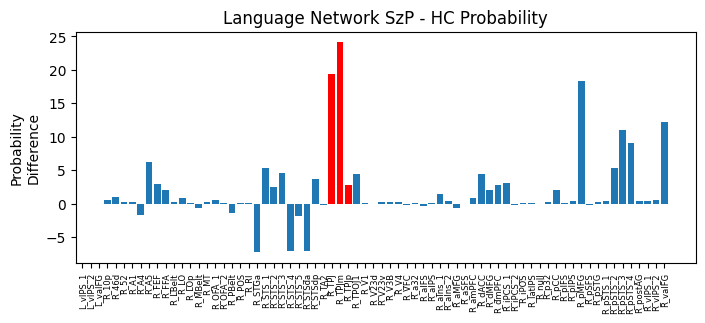

In [746]:
c = np.array(["r" if "tpj" in v.lower() else "C0" for v in topo_roi_values.keys()])
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(topo_roi_values.keys(), topo_roi_values.values(), color=c)
ax.set(ylabel="Probability\nDifference", title=f"{network_interest} Network SzP - HC Probability")
plt.xticks(fontsize=6, color='black', rotation=90);

In [688]:
r_tpj_labels = parc.subset_labels(["R_TPJ", "L_TPJ"])

### PM Sizes differences
[] surface maps of expansion and contraction between szp vs hc
[] quantify stability: variable rs times, using HCP, etc

Text(0.5, 1.0, 'Default_Parietal Spatial Probability')

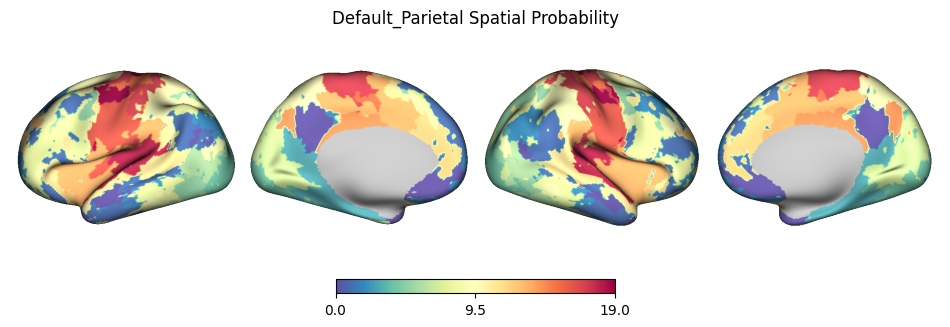

In [311]:
spatial_values_i = CAP_tools.utils.cifti_map(None, vertex_networks, example_cifti)

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(spatial_values_i, cmap=plt.cm.Spectral_r, ax=ax)
ax.set_title(f"{network_labels[sp_index]} Spatial Probability")

Text(0.5, 1.0, 'Visual_Dorsal/VentralStream Spatial Probability')

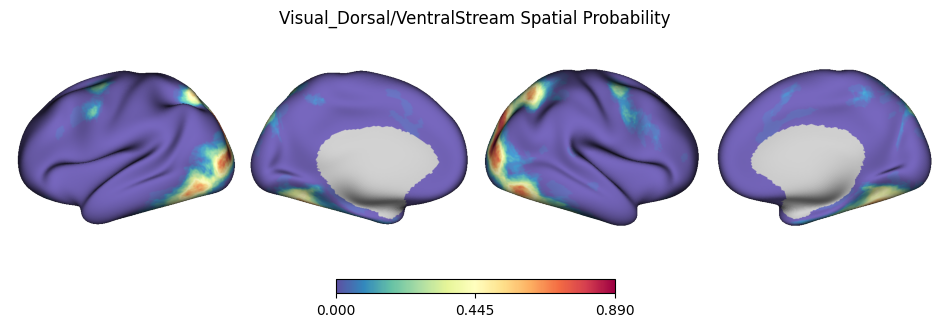

In [265]:
spatial_values_i = CAP_tools.utils.cifti_map(None, spatial[sp_index], example_cifti)

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(spatial_values_i, cmap=plt.cm.Spectral_r, ax=ax)
ax.set_title(f"{network_labels[sp_index]} Spatial Probability")


# Load infomaps Parcellations

In [90]:
sparsity = 0.1
dist_threshold = 10
subcortex = True
prefix = "example"

In [91]:
example_cifti = nb.load(va.constants.EXAMPLE_DTSERIES)

In [92]:
outputs_path = "/data/data7/network_control/projects/voxel_analysis/tests/outputs/"

subcortex_tag = "_SC" if subcortex else ""
param_tag = f"S{sparsity * 10:.0f}_D{dist_threshold}{subcortex_tag}"
partition_path = os.path.join(outputs_path, f"{prefix}_parcellation_{param_tag}.npy")

In [95]:
def process_partition(partition, cifti, min_voxels=0, n_vertices=91_282, filter_subcortex=True):
    """ """
    index, groups = partition
    # if filter_subcortex:
    #     subcortex_index = index >= (32_492 * 2)
    #     index, groups = index[~subcortex_index], np.unique(groups[~subcortex_index], return_inverse=True)[1]

    groups = np.random.permutation(np.max(groups))[groups - 1]    
    unique_groups, counts = np.unique(groups, return_counts=True)
    count_filter = np.isin(groups, unique_groups[counts >= min_voxels])
    
    vertex_labels = np.full(n_vertices, fill_value=np.nan)
    vertex_labels[index] = groups
    # vertex_labels[index[count_filter]] = groups[count_filter]
    
    precision_map_values = CAP_tools.utils.cifti_map(None, vertex_labels, cifti)
    # precision_map_values = CAP_tools.utils.cifti_map(index, groups, cifti)
    return precision_map_values, (index, groups)

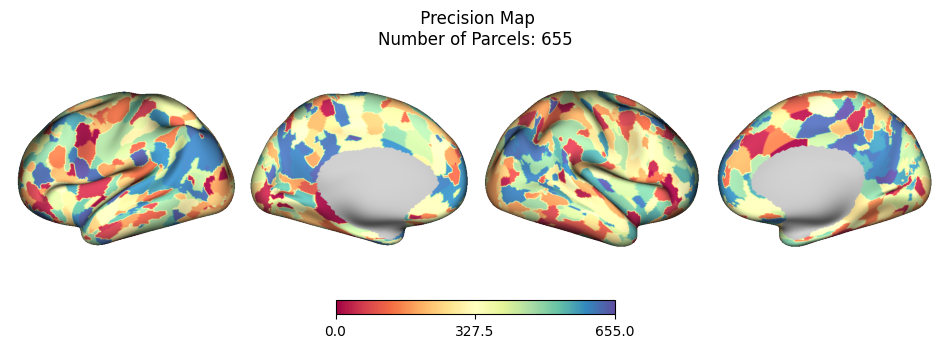

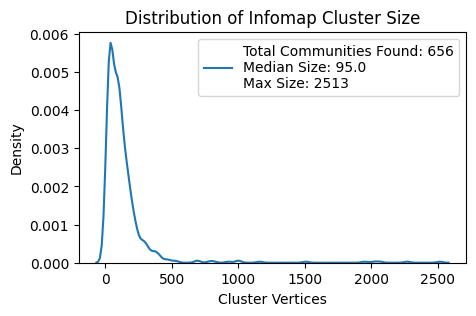

In [96]:
partition = np.load(partition_path)
precision_map_values, partition = process_partition(partition, example_cifti)

va.pm.plot_precision_map(precision_map_values)
va.pm.precision_map_QC_plots(partition)
# va.pm.write_dlabel_precision_map(precision_map_values, dlabel_path, label="example_precision_map")

# Distance and Subcortical Masking

In [69]:
sfm.get_cortex_mask(rs_dtseries)

array([ True,  True,  True, ..., False, False, False])

In [70]:
dist_dir = "/data/data7/network_control/projects/network_control/resources/brain_distances"
ex_dist_txt_path = os.path.join(dist_dir, "Schaefer400_geodesic_distmat_R.txt")
ex_dist_txt_path = os.path.join(dist_dir, "dense_geodesic_distmat_R.txt")

geodesic_distmat_L_path = os.path.join(dist_dir, "dense_geodesic_distmat_L.txt")
geodesic_distmat_R_path = os.path.join(dist_dir, "dense_geodesic_distmat_R.txt")

In [90]:
from scipy.sparse import lil_matrix

def create_sparse_matrix_from_txt(file_path, threshold=10.0, num_voxels=32_492):
    sparse_matrix = lil_matrix((num_voxels, num_voxels), dtype=np.float32)

    pbar = tqdm(total=num_voxels)
    with open(file_path, 'r') as f:
        for i, line in enumerate(f):
            distances = line.strip().split()
            for j, dist in enumerate(distances):
                dist_value = float(dist)
                if dist_value <= threshold and i != j:
                    sparse_matrix[i, j] = dist_value
            pbar.update(1)
    return sparse_matrix

In [91]:
threshold = 30
geodesic_dist_mask_R = create_sparse_matrix_from_txt(geodesic_distmat_R_path, threshold=threshold)
geodesic_dist_mask_L = create_sparse_matrix_from_txt(geodesic_distmat_L_path, threshold=threshold)

  0%|          | 0/32492 [00:00<?, ?it/s]

  0%|          | 0/32492 [00:00<?, ?it/s]

In [92]:
geodesic_mask = scipy.sparse.block_diag([geodesic_dist_mask_L, geodesic_dist_mask_R])
geodesic_mask.resize(91282, 91282)
geodesic_mask = geodesic_mask.tocsr()

geodesic_mask_path = os.path.join(dist_dir, f"geodesic_mask_{threshold}.npz")
scipy.sparse.save_npz(geodesic_mask_path, geodesic_mask)
geodesic_mask

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 111710086 stored elements and shape (91282, 91282)>

# Calculate Euclidian Mask

In [643]:
subcortex_index = ~sfm.get_cortex_mask(rs_dtseries)
subcortex_mask_path = os.path.join(dist_dir, "subcortex_mask.npy")
np.save(subcortex_mask_path, subcortex_index)

In [644]:
subcortex_index = np.load(subcortex_mask_path)
geodesic_mask = scipy.sparse.load_npz(geodesic_mask_path)

In [639]:
sc = tmt.matrix.SparseCorrelator.run(rs_voxels[:, :], sparsity_percent=0.1, mask=geodesic_mask,
                                     exclude_index=subcortex_index,
                                     block_size=4000)

SparseCorrelator Block Analysis:   0%|          | 0/8464.0 [00:00<?, ?it/s]

In [645]:
sc = tmt.matrix.Runner.run(rs_voxels[:, :], mask=geodesic_mask,
                                     exclude_index=subcortex_index,
                                     block_size=4000)

<Axes: ylabel='Density'>

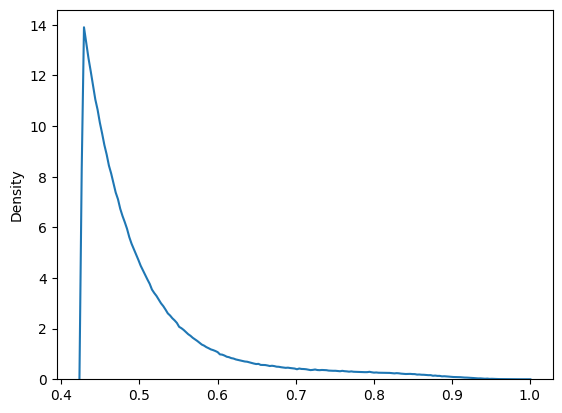

In [37]:
sns.kdeplot(sc.data, bw_method=0.01)

In [38]:
from sklearn.cluster import SpectralClustering
from scipy.sparse import csr_matrix

# Assuming 'sparse_matrix' is your scipy sparse matrix
# model = SpectralClustering(n_clusters=3, affinity='precomputed', n_init=100)
# labels = model.fit_predict(sc)

In [51]:
G = nx.from_scipy_sparse_matrix(sc)

AttributeError: module 'networkx' has no attribute 'from_scipy_sparse_matrix'

In [50]:
import networkx as nx
import community as community_louvain

partition = community_louvain.best_partition(G)

AttributeError: module 'networkx' has no attribute 'from_scipy_sparse_matrix'

In [41]:
(sc.sum(axis=1) == 0).sum()

np.int64(105)

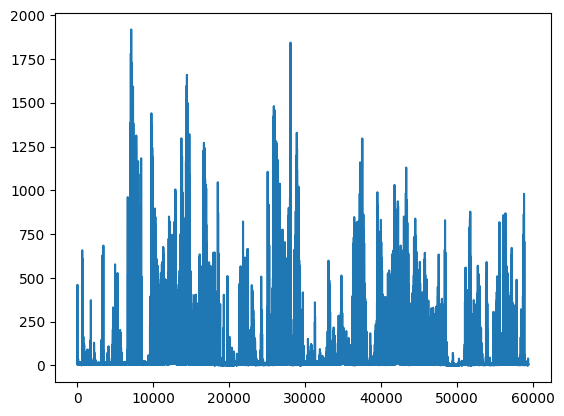

In [49]:
plt.plot(sc.getnnz(axis=0))

# Infomap

# EV Maxs

In [129]:
ev_maxs = tmt.matrix.block_analysis(voxel_data[:, :10000], tmt.matrix.ev_aggregator,
                                    device="mps", use_torch=True)

  0%|          | 0/10 [00:00<?, ?it/s]

In [56]:
(ev_maxs >= 0.5).mean() * 100

np.float64(86.18)

<Axes: ylabel='Density'>

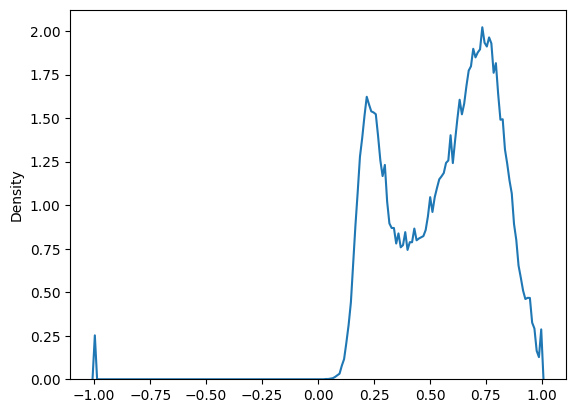

In [179]:
sns.kdeplot(ev_maxs, bw_method=0.01)

[] within parcel vs out of parcel correlations for voxel level

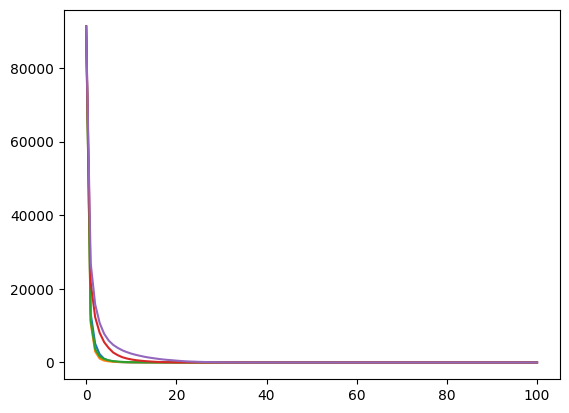

In [558]:
plt.plot(na_counts.T);

In [543]:
na_counts = {thres: [] for thres in np.linspace(0, 1, 101)}